In [8]:
from pathlib import Path
import pandas as pd
import json
import yaml
import logging
from typing import Literal
from joblib import Parallel, delayed

# ignore runtime warnings
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from deckard.utils import ConfigBase

logger = logging.getLogger(__name__)

In [ ]:
class ResultConfig(ConfigBase):
    directory: str = "outputs/"
    params_regex : str = "**/params.yaml"
    scores_regex : str = "**/scores.json"
    output_file : str = "outputs/combined_results.csv"
    
    def __post_init__(self):
        self.directory = Path(self.directory).as_posix()
        glob = Path(self.directory).glob
        self.params_files = sorted(list(glob(self.params_regex)), key=lambda f: f.parent.as_posix())
        self.score_files = sorted(list(glob(self.scores_regex)), key=lambda f: f.parent.as_posix())
        # Remove any score files that do not have a corresponding params file and vice versa
        score_file_stems = set([f.parent.as_posix() for f in self.score_files])
        params_file_stems = set([f.parent.as_posix() for f in self.params_files])
        common_stems = score_file_stems.intersection(params_file_stems)
        logger.info(f"Found {len(self.score_files)} score files and {len(self.params_files)} params files before matching.")
        self.score_files = [f for f in self.score_files if f.parent.as_posix() in common_stems]
        self.params_files = [f for f in self.params_files if f.parent.as_posix() in common_stems]
    
    def __iter__(self):
        for score_file, param_file in zip(self.score_files, self.params_files):
            yield score_file, param_file
    
    def _read_pair(score_file, params_file):
            with open(score_file, "r") as sf:
                score_dict = json.load(sf)
            score_df = pd.json_normalize(score_dict)
            with open(params_file, "r") as pf:
                params_dict = yaml.safe_load(pf)
            params_df = pd.json_normalize(params_dict)
            combined_df = pd.concat([params_df, score_df], axis=1)
            return combined_df
    def __call__(self):
        big_df = pd.DataFrame()
        

        pairs = list(zip(self.score_files, self.params_files))
        if pairs:
            results = Parallel(n_jobs=-1)(delayed(self._read_pair)(s, p) for s, p in pairs)
            # filter out any None results and concatenate
            results = [r for r in results if r is not None]
            if results:
                big_df = pd.concat(results, ignore_index=True)  
        if self.output_file:
            big_df.to_csv(self.output_file, index=False)
        return big_df
    

result_config = ResultConfig()
big_df = result_config()

INFO:__main__:Found 4381 score files and 4382 params files before matching.


In [ ]:

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer

metric_columns = [
    "accuracy",
    "membership_inference_accuracy",
    "evasion_success",
    "inferred_sex_accuracy",
]

# All numeric columns are relevant for imputation
relevant_columns = big_df.select_dtypes(include=["number"]).columns.tolist()


for metric in metric_columns:
    assert metric in relevant_columns, f"Metric column '{metric}' not found in DataFrame or is not numeric."

sig_figs = [4, 2, 2, 3]




class ResultImputerConfig(ConfigBase):
    metric_columns: list 
    sig_figs: list 
    imputer_type: Literal["knn", "iterative"] = "knn"
    imputer_params: dict = {}
    
    def __post_init__(self):
        assert len(self.metric_columns) == len(self.sig_figs), "Length of metric_columns and sig_figs must be the same."
    
    def __call__(self, df: pd.DataFrame) -> pd.DataFrame:
        imputed_df = df.copy().reset_index(drop=True)
        if self.imputer_type == "knn":
            imputer = KNNImputer(**self.imputer_params)
        elif self.imputer_type == "iterative":
            
            imputer = IterativeImputer(**self.imputer_params)
        elif self.imputer_type == "simple":
            imputer = SimpleImputer(**self.imputer_params)
        else:
            raise ValueError(f"Unknown imputer_type: {self.imputer_type}")
        
        relevant_columns = self.metric_columns
        imputed_values = imputer.fit_transform(imputed_df[relevant_columns])
        imputed_df[relevant_columns] = imputed_values
        
        # Round the imputed metrics to the specified significant figures
        for col, sig_fig in zip(self.metric_columns, self.sig_figs):
            imputed_df[col] = imputed_df[col].round(sig_fig)
        
        return imputed_df
    
big_df = ResultImputerConfig(metric_columns=metric_columns, sig_figs=sig_figs)(big_df)

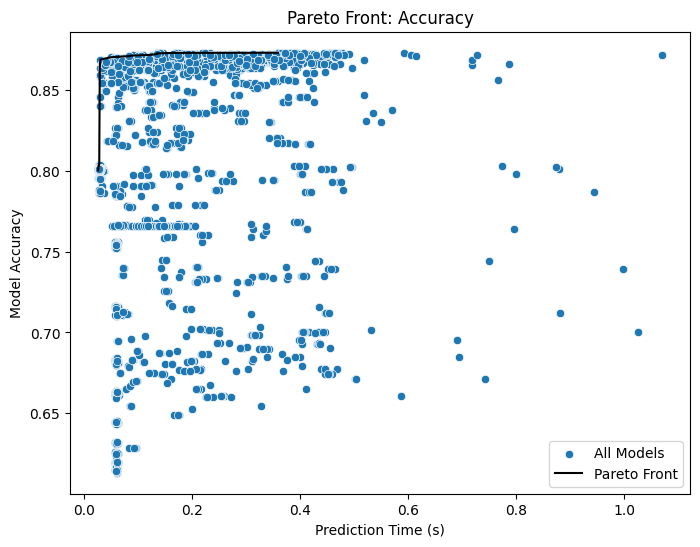

Saved plot to pareto_accuracy.png


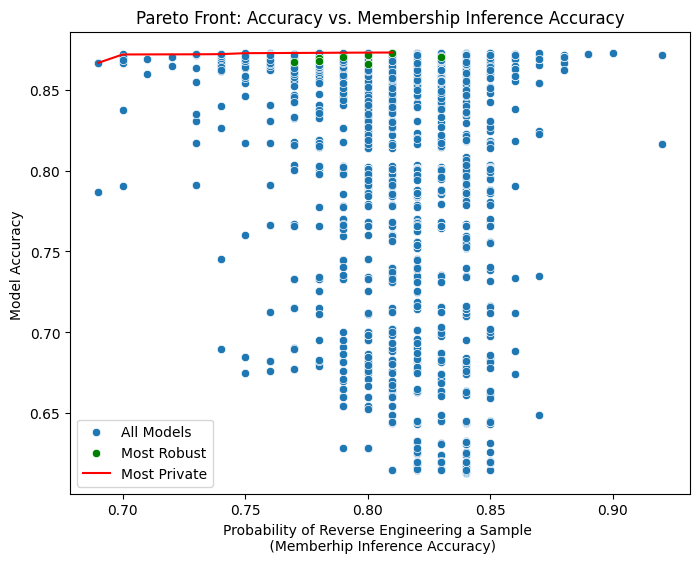

Saved plot to pareto_accuracy_vs_membership_inference.png


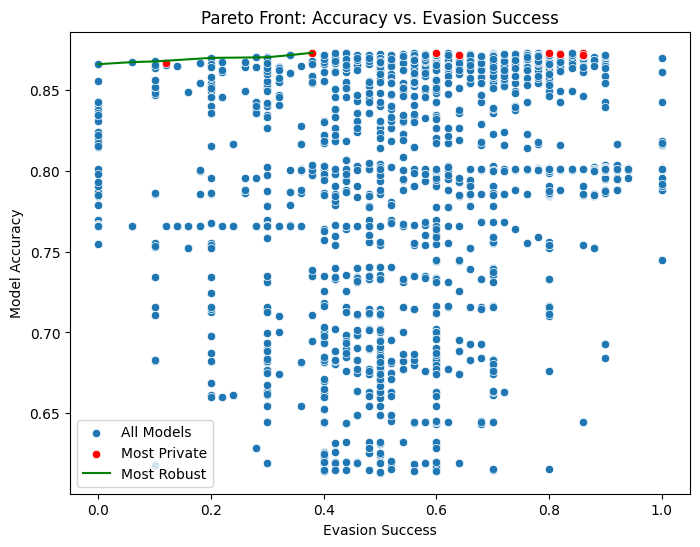

Saved plot to pareto_accuracy_vs_evasion.png


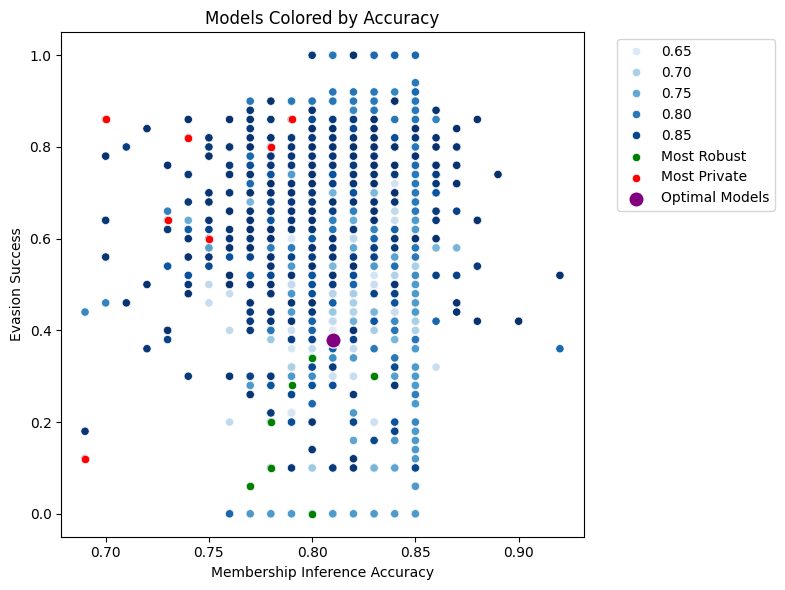

Saved plot to pareto_membership_inference_vs_evasion_colored_by_accuracy.png
Pareto optimal configurations for accuracy, membership inference accuracy, and evasion accuracy:


In [11]:
import paretoset
import seaborn as sns
import matplotlib.pyplot as plt
# Round 'accuracy' to 4 decimal places to avoid floating point issues
# big_df["accuracy"] = big_df["accuracy"].round(4)
# big_df["membership_inference_accuracy"] = big_df["membership_inference_accuracy"]
dual_objective = paretoset.paretoset(big_df[["accuracy", "prediction_time"]].to_numpy(), sense=["max", "min"])
pareto_df0 = big_df[dual_objective]
pareto_df0 = pareto_df0.sort_values(by=["accuracy", "prediction_time"], ascending=[ False, True])
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=big_df, x="prediction_time", y="accuracy", ax=ax, label="All Models")
sns.lineplot(data=pareto_df0, x="prediction_time", y="accuracy", ax=ax, color="black", label="Pareto Front")
ax.set_title("Pareto Front: Accuracy")
ax.set_xlabel("Prediction Time (s)")
ax.set_ylabel("Model Accuracy")
ax.legend()
plt.show()
plot_file = "pareto_accuracy.png"
fig.savefig(plot_file)
print(f"Saved plot to {plot_file}")

big_df_encoded = imputed_df.copy()
big_df_encoded["accuracy"] = big_df_encoded["accuracy"].round(4)
big_df_encoded["membership_inference_accuracy"] = big_df_encoded["membership_inference_accuracy"].round(2)
big_df_encoded["evasion_success"] = big_df_encoded["evasion_success"].round(2)

dual_objective1 = paretoset.paretoset(big_df_encoded[["accuracy", "membership_inference_accuracy",]].to_numpy(), sense=["max", "min",])
pareto_df1 = big_df_encoded[dual_objective1]
pareto_df1 = pareto_df1.sort_values(by=["accuracy", "membership_inference_accuracy"], ascending=[ False, True])

dual_objective2 = paretoset.paretoset(big_df_encoded[["accuracy", "evasion_success",]].to_numpy(), sense=["max", "min",])
pareto_df2 = big_df_encoded[dual_objective2]
pareto_df2 = pareto_df2.sort_values(by=["accuracy", "evasion_success"], ascending=[ False, True])

triple_objective = paretoset.paretoset(big_df_encoded[["accuracy", "membership_inference_accuracy", "evasion_success"]].to_numpy(), sense=["max", "min", "min"])
pareto_df3 = big_df_encoded[triple_objective]
pareto_df3 = pareto_df3.sort_values(by=["accuracy", "membership_inference_accuracy", "evasion_success"], ascending=[ False, True, True])

# Create 1 fig with 2 subplots: left is accuracy vs evasion_success, right is accuracy vs membership_inference_accuracy
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=big_df_encoded, x="membership_inference_accuracy", y="accuracy", ax=ax, label="All Models")
sns.scatterplot(data=pareto_df2, x="membership_inference_accuracy", y="accuracy", color="green", label="Most Robust")
sns.lineplot(data=pareto_df1, x="membership_inference_accuracy", y="accuracy", ax=ax, color="red", label="Most Private")
ax.set_title("Pareto Front: Accuracy vs. Membership Inference Accuracy")
ax.set_xlabel("Probability of Reverse Engineering a Sample \n (Memberhip Inference Accuracy)")
ax.set_ylabel("Model Accuracy ")
ax.legend()
plt.show()
plot_file = "pareto_accuracy_vs_membership_inference.png"
fig.savefig(plot_file)
print(f"Saved plot to {plot_file}")



fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=big_df_encoded, x="evasion_success", y="accuracy", ax=ax, label="All Models")
sns.scatterplot(data=pareto_df1, x="evasion_success", y="accuracy", color="red", label="Most Private")
sns.lineplot(data=pareto_df2, x="evasion_success", y="accuracy", ax=ax, color="green", label="Most Robust")
ax.set_title("Pareto Front: Accuracy vs. Evasion Success")
ax.set_xlabel("Evasion Success")
ax.set_ylabel("Model Accuracy")
ax.legend()
plt.show()
plot_file = "pareto_accuracy_vs_evasion.png"
fig.savefig(plot_file)
print(f"Saved plot to {plot_file}")




fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=big_df_encoded, x="membership_inference_accuracy", y="evasion_success", hue="accuracy", palette="Blues", ax=ax)
# sns.scatterplot(data=pareto_df3, x="membership_inference_accuracy", y="evasion_success", color="purple", label="Pareto Set", ax=ax)

dual_objective_combined = [dual_objective1[i] and dual_objective2[i] for i in range(len(dual_objective1))]
pareto_df_combined = big_df_encoded[dual_objective_combined]

sns.scatterplot(data=pareto_df2, x="membership_inference_accuracy", y="evasion_success", color="green", label="Most Robust", ax=ax, markers="accuracy")
sns.scatterplot(data=pareto_df1, x="membership_inference_accuracy", y="evasion_success", color="red", label="Most Private", ax=ax)
sns.scatterplot(data=pareto_df_combined, x="membership_inference_accuracy", y="evasion_success", color="purple", ax=ax, label="Optimal Models", markers="", s=120)

ax.set_title("Models Colored by Accuracy")
ax.set_xlabel("Membership Inference Accuracy")
ax.set_ylabel("Evasion Success")
# move legend outside of plot
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plot_file = "pareto_membership_inference_vs_evasion_colored_by_accuracy.png"
fig.savefig(plot_file)
print(f"Saved plot to {plot_file}")
print("Pareto optimal configurations for accuracy, membership inference accuracy, and evasion accuracy:")

In [ ]:
from sklearn.preprocessing import OneHotEncoder
# Import tfidvectorizer

duration_col = "attack_generation_time"
event_col = "membership_inference_accuracy"

metric_cols = [duration_col, event_col]
diff_cols = ["model_alias", "defense_alias", "attack_alias",  "accuracy", "prediction_time", "membership_inference_accuracy", "evasion_success", "training_time"]
relevant_cols = metric_cols + diff_cols
# remove duplicate column names while preserving order (there was a duplicate 'membership_inference_accuracy')
relevant_cols = list(dict.fromkeys(relevant_cols))
aft_df = big_df[relevant_cols].copy()
# aft_df['average_attack_success'] = (imputed_df['membership_inference_accuracy'] + (1-imputed_df['evasion_success']))/2

# Encoding categorical variables (only if any categorical columns exist and are present)
categorical_cols = []
for col in diff_cols:
    if col in aft_df.columns:
        if  aft_df[col].dtype.name == 'category' or aft_df[col].dtype == 'object':
            categorical_cols.append(col)
        

if categorical_cols:
    # support older and newer sklearn versions for the sparse parameter
    try:
        encoder = OneHotEncoder(sparse_output=False, drop="if_binary")
    except TypeError:
        encoder = OneHotEncoder(sparse=False, drop="if_binary")
    encoded_cats = encoder.fit_transform(aft_df[categorical_cols])
    encoded_cat_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_cols), index=aft_df.index)
    aft_df = pd.concat([aft_df, encoded_cat_df], axis=1)
    aft_df = aft_df.drop(columns=categorical_cols)



# Ensure metric columns exist and drop rows missing required metrics
aft_df = aft_df.dropna(subset=metric_cols)

# Drop non-unique columns
aft_df = aft_df.loc[:, ~aft_df.columns.duplicated()]

# Convert object columns that are numeric-like to numeric where possible
for col in aft_df.columns:
    if aft_df[col].dtype == 'object':
        aft_df[col] = pd.to_numeric(aft_df[col], errors='ignore')

In [13]:
from lifelines import CoxPHFitter, GeneralizedGammaRegressionFitter, LogLogisticAFTFitter, LogNormalAFTFitter, WeibullAFTFitter, PiecewiseExponentialRegressionFitter
from lifelines.exceptions import ConvergenceError

import numpy as np
fiter_dict = {
    "cox": CoxPHFitter,
    "generalized_gamma": GeneralizedGammaRegressionFitter,
    "exponential" : PiecewiseExponentialRegressionFitter,
    "log_logistic_aft": LogLogisticAFTFitter,
    "log_normal_aft": LogNormalAFTFitter,
    "weibull_aft": WeibullAFTFitter
}
scores = {}
def initialize_survival_model(fitter_name, fitter_class, fitter_params={}):
    if fitter_name == "exponential":
        # Define breakpoints for Piecewise Exponential Fitter
        breakpoints = np.percentile(aft_df[duration_col], [100])
        fitter = fitter_class(breakpoints=breakpoints, **fitter_params)
    else:
        fitter = fitter_class(**fitter_params)
    return fitter


def select_best_model(fitters, scores):
    score_df = pd.DataFrame.from_dict(scores, orient="index")
    # sort by log likelihood, descending and concordance index descending
    score_df = score_df.sort_values(by=["concordance_index", "log_likelihood",], ascending=[True, True])
    best_model_name = score_df.index[-1]
    print(f"Best model selected: {best_model_name} with scores:\n{score_df.loc[best_model_name]}")
    best_model = fitters[best_model_name]
    return best_model


def fit_all_models(aft_df, event_col, duration_col, plot_file=None, fitter_params={}):
    fitters = {}
    scores = {}
    # Determine if fitter_params contains the keys for each fitter
    fitter_specific_params = {}
    for fitter_name in fiter_dict.keys():
        if fitter_name in fitter_params:
            fitter_specific_params[fitter_name] = fitter_params[fitter_name]
        else:
            fitter_specific_params[fitter_name] = {}
    for fitter_name, fitter_class in fiter_dict.items():
        subset_params = fitter_specific_params.get(fitter_name, {})
        subset_params = {**fitter_params, **subset_params}
        fitter = initialize_survival_model(fitter_name, fitter_class, subset_params)
        try:
            assert duration_col in aft_df.columns, f"Duration column '{duration_col}' not found in DataFrame."
            assert event_col in aft_df.columns, f"Event column '{event_col}' not found in DataFrame."
        
            fitter.fit(aft_df, duration_col=duration_col, event_col=event_col)
            fitters[fitter_name] = fitter
            scores[fitter_name] = {} if fitter_name not in scores else scores[fitter_name]
            scores[fitter_name]['log_likelihood'] = fitter.score(aft_df, scoring_method="log_likelihood")
            scores[fitter_name]['concordance_index'] = fitter.score(aft_df, scoring_method="concordance_index")
            if plot_file:
                fitter_title = fitter_name.replace("_", " ").title()
                fig, ax = plt.subplots(figsize=(8, 6))
                fitter.plot(ax=ax)
                plt.title(f"{fitter_title} Model for Average Attack Success")
                plt.xlabel("Effect of Covariates on Survival Time")
                plt.ylabel("Covariates")
                plt.savefig(f"{fitter_name}_{plot_file}")
                plt.show()
                plt.close(fig)
            # fitter.plot()
            # plt.title(f"{fitter_title} Model for Average Attack Success")
            # plt.xlabel("Effect of Covariates on Survival Time")
            # plt.ylabel("Covariates")
            # plt.show()
        except ConvergenceError as e:
            print(f"{fitter_name} did not converge.") 
        except Exception as e:
            print(f"An error occurred while fitting {fitter_name}: {e}")
            raise e
    return fitters, scores



cox did not converge.
generalized_gamma did not converge.
Best model selected: log_logistic_aft with scores:
log_likelihood       1.601109
concordance_index    0.827077
Name: log_logistic_aft, dtype: float64


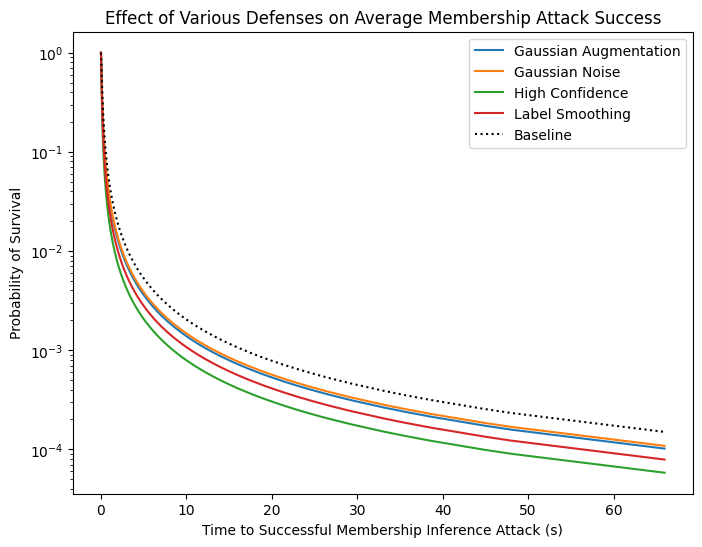

Saved plot to partial_effects_membership_inference.png
cox did not converge.
generalized_gamma did not converge.
Best model selected: log_normal_aft with scores:
log_likelihood       0.767344
concordance_index    0.877514
Name: log_normal_aft, dtype: float64


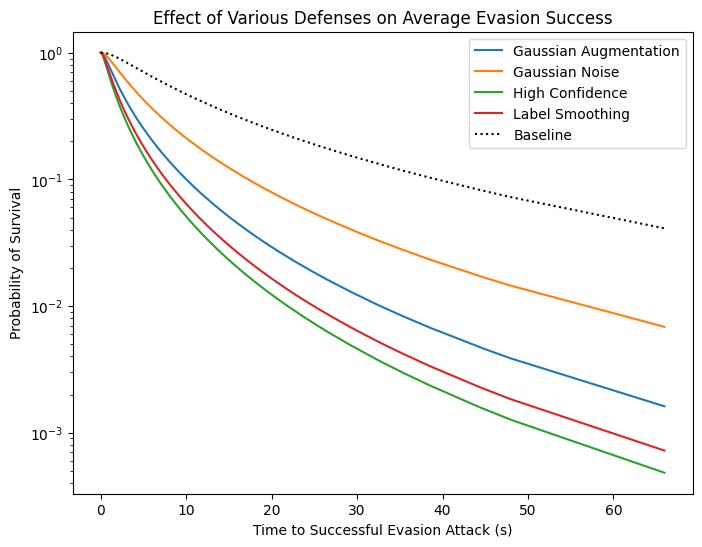

Saved plot to partial_effects_evasion.png
cox did not converge.
Best model selected: generalized_gamma with scores:
log_likelihood      -4512.597322
concordance_index       0.883743
Name: generalized_gamma, dtype: float64


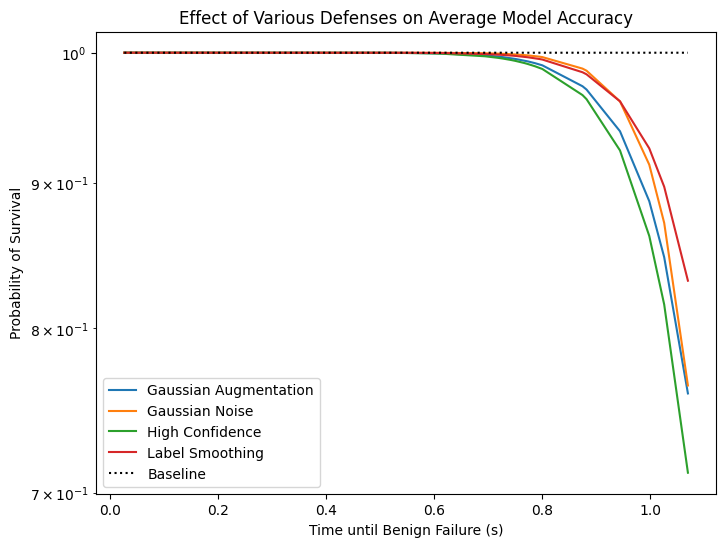

Saved plot to partial_effects_benign_accuracy.png


In [14]:


def determine_values_from_cat_cols(cols):
    num_cols = len(cols)
    values = []
    for i in range(num_cols):
        value = [0] * num_cols
        value[i] = 1
        values.append(value)
    if len(values) == 1:
        # If only one column, add a zero vector to show effect of absence
        values.insert(0, [0])
    return values

def determine_values_from_numeric_cols(col):
    min_ = col.min()
    max_ = col.max()
    # If the range is large, use logspace
    if abs(max_ - min_) / max(min_, 1e-6) > 100: # large range
        values = np.logspace(np.log10(min_), np.log10(max_), num=5).tolist()
    else:
        values = np.linspace(min_, max_, num=5).tolist()
    return values




def partial_plot(model, cols, values, title, xlabel, ylabel, xscale="log", yscale=None, filename=None, prefix=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    model.plot_partial_effects_on_outcome(covariates=cols, values=values, ax=ax)
    # Rename legend labels
    old_labels = ax.get_legend_handles_labels()[1]
    if prefix is None:
        prefix = ""
    names = [col.replace(prefix, "").split(".")[-1].split("=1")[0] for col in old_labels]
    names = [name.replace("_", " ").title() for name in names]
    plt.legend(names)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if xscale:
        plt.xscale(xscale)
    if yscale:
        plt.yscale(yscale)
    plt.show()
    if filename:
        fig.savefig(filename)
        print(f"Saved plot to {filename}")
        

from deckard.utils import ConfigBase

class PartialPlotConfig(ConfigBase):
    title: str
    xlabel: str
    ylabel: str
    xscale: str = "log"
    yscale: str = None
    filename: str = None


class SurvivalModelConfig(ConfigBase):
    event_col: str
    duration_col: str
    prefix: str 
    plot_config: PartialPlotConfig
    plot_config_list: list[PartialPlotConfig] = []
    
    
    def __post_init__(self):
        # Assert that plot_config and plot_config_list are not both set
        if self.plot_config and self.plot_config_list:
            raise ValueError("Both plot_config and plot_config_list cannot be set at the same time.")
        # If only plot_config is set, convert it to a list
        if self.plot_config and not self.plot_config_list:
            self.plot_config_list = [self.plot_config]
        return super().__post_init__()
    
    
    def __iter__(self):
        return iter(self.plot_config_list)
    
    def __call__(self):
        for plot_config in self.plot_config_list:
            fitters, scores = fit_all_models(aft_df, self.event_col, self.duration_col)
            best_model = select_best_model(fitters, scores)
            kwargs = {
                "title": plot_config.title,
                "xlabel": plot_config.xlabel,
                "ylabel": plot_config.ylabel,
                "xscale": plot_config.xscale,
                "yscale": plot_config.yscale,
                "filename": plot_config.filename,
            }
            prefix_cols = [col for col in aft_df.columns if col.startswith(self.prefix)]
            if len(prefix_cols) > 1:
                prefix_values = determine_values_from_cat_cols(prefix_cols)
            else:
                prefix_values = determine_values_from_numeric_cols(aft_df[prefix_cols[0]])
            partial_plot(best_model, prefix_cols, prefix_values, prefix=self.prefix, **kwargs)
            

survival_model_configs = [
    SurvivalModelConfig(
        event_col="membership_inference_accuracy",
        duration_col="attack_generation_time",
        prefix="defense_alias_",
        plot_config=PartialPlotConfig(
            title="Effect of Various Defenses on Average Membership Attack Success",
            xlabel="Time to Successful Membership Inference Attack (s)",
            ylabel="Probability of Survival",
            yscale="log",
            xscale=None,
            filename="partial_effects_membership_inference.png",
        ),
    ),
    SurvivalModelConfig(
        event_col="evasion_success",
        duration_col="attack_generation_time",
        prefix="defense_alias_",
        plot_config=PartialPlotConfig(
            title="Effect of Various Defenses on Average Evasion Success",
            xlabel="Time to Successful Evasion Attack (s)",
            ylabel="Probability of Survival",
            yscale="log",
            xscale=None,
            filename="partial_effects_evasion.png",
        ),
    ),
    SurvivalModelConfig(
        event_col="accuracy",
        duration_col="prediction_time",
        prefix="defense_alias_",
        plot_config=PartialPlotConfig(
            title="Effect of Various Defenses on Average Model Accuracy",
            xlabel="Time until Benign Failure (s)",
            ylabel="Probability of Survival",
            yscale="log",
            xscale=None,
            filename="partial_effects_benign_accuracy.png",
        ),
    ),
]
for config in survival_model_configs:
    config()  # Call the config to execute the fitting and plotting